In [ ]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

root_dir = r"C:\Users\HP\Desktop\trashnet_split"
train_dir = r"C:\Users\HP\Desktop\trashnet_split\train"
val_dir   = r"C:\Users\HP\Desktop\trashnet_split\val"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
print(f"Using device: {device}")

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30           
LR         = 1e-4         

MODEL_PATH = r"C:\Users\HP\Desktop\trashnet_best_model.pth"

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

class_names = train_dataset.classes
print(f"Detected classes: {class_names}")
# Expected output: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)     
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

best_acc = 0.0
print("Training started...\n")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_acc = 100. * train_correct / train_total


    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total

    
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} Acc: {train_acc:6.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} Acc: {val_acc:6.2f}%")

 
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_accuracy': val_acc,
            'class_names': class_names
        }, MODEL_PATH)
        print(f"Best model saved! Val accuracy: {val_acc:.2f}%\n")

print(f"\nTraining finished!")
print(f"Best validation accuracy: {best_acc:.2f}%")
print(f"Model saved at: {MODEL_PATH}")

Using device: cpu
Detected classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training started...

Epoch  1/30 | Train Loss: 0.8633 Acc:  70.03% | Val Loss: 0.5622 Acc:  81.68%
Best model saved! Val accuracy: 81.68%

Epoch  2/30 | Train Loss: 0.3780 Acc:  87.85% | Val Loss: 0.5324 Acc:  82.72%
Best model saved! Val accuracy: 82.72%

Epoch  3/30 | Train Loss: 0.2746 Acc:  92.57% | Val Loss: 0.4427 Acc:  85.34%
Best model saved! Val accuracy: 85.34%

Epoch  4/30 | Train Loss: 0.1632 Acc:  94.84% | Val Loss: 0.4518 Acc:  85.34%
Epoch  5/30 | Train Loss: 0.1244 Acc:  97.50% | Val Loss: 0.4366 Acc:  87.96%
Best model saved! Val accuracy: 87.96%

Epoch  6/30 | Train Loss: 0.1410 Acc:  96.08% | Val Loss: 0.3891 Acc:  89.01%
Best model saved! Val accuracy: 89.01%

Epoch  7/30 | Train Loss: 0.0973 Acc:  97.45% | Val Loss: 0.4312 Acc:  87.43%
Epoch  8/30 | Train Loss: 0.0795 Acc:  97.96% | Val Loss: 0.4074 Acc:  88.48%
Epoch  9/30 | Train Loss: 0.1187 Acc:  98.30% | Val Loss: 

In [6]:
MODEL_PATH = r"C:\Users\HP\Desktop\trashnet_best_model.pth"
TEST_DIR = r"C:\Users\HP\Desktop\trashnet_split\test"  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(TEST_DIR, transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

checkpoint = torch.load(MODEL_PATH)
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 6)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = 100 * correct / total
print(f"\n acc test: {acc:.2f}%")
print(f"true: {correct} in {total}")


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



 acc test: 85.12%
true: 326 in 383


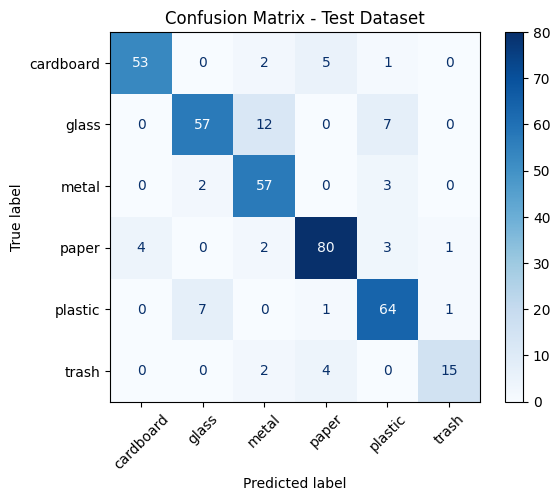

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:   
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Test Dataset")
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)


              precision    recall  f1-score   support

   cardboard       0.93      0.87      0.90        61
       glass       0.86      0.75      0.80        76
       metal       0.76      0.92      0.83        62
       paper       0.89      0.89      0.89        90
     plastic       0.82      0.88      0.85        73
       trash       0.88      0.71      0.79        21

    accuracy                           0.85       383
   macro avg       0.86      0.84      0.84       383
weighted avg       0.86      0.85      0.85       383

Confusion Matrix:
 [[53  0  2  5  1  0]
 [ 0 57 12  0  7  0]
 [ 0  2 57  0  3  0]
 [ 4  0  2 80  3  1]
 [ 0  7  0  1 64  1]
 [ 0  0  2  4  0 15]]
